In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/AML_Lab/dataset_Melbourne_housing_FULL_exp_12.csv')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [14]:
df = df.dropna()

X = df.drop('Price', axis=1)
X = pd.get_dummies(X)

y = df['Price']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge MSE: 85594070009.34525
Ridge R2: 0.7772214050169969


In [7]:
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso MSE: 89944133733.50972
Lasso R2: 0.7658993463223924


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.101e+13, tolerance: 3.417e+11
  model = cd_fast.enet_coordinate_descent(


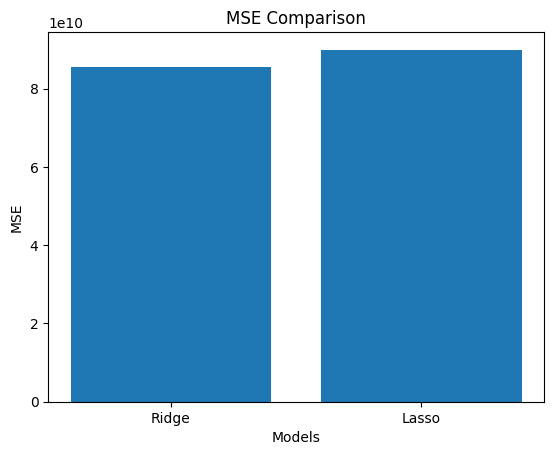

In [8]:
models = ['Ridge', 'Lasso']
mse_values = [
    mean_squared_error(y_test, y_pred_ridge),
    mean_squared_error(y_test, y_pred_lasso)
]

plt.figure()
plt.bar(models, mse_values)
plt.xlabel('Models')
plt.ylabel('MSE')
plt.title('MSE Comparison')
plt.show()

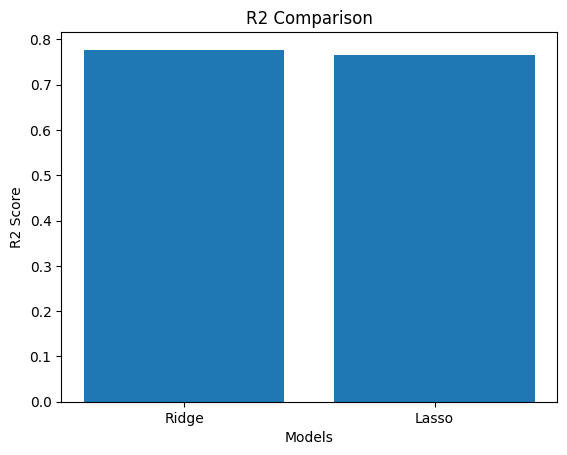

In [9]:
r2_values = [
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]

plt.figure()
plt.bar(models, r2_values)
plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.title('R2 Comparison')
plt.show()

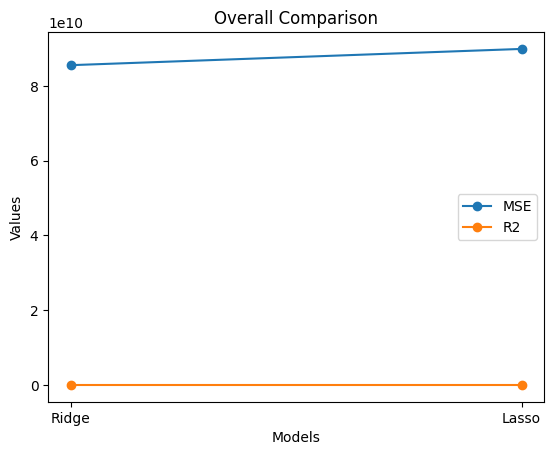

In [10]:
plt.figure()
plt.plot(models, mse_values, marker='o', label='MSE')
plt.plot(models, r2_values, marker='o', label='R2')
plt.xlabel('Models')
plt.ylabel('Values')
plt.title('Overall Comparison')
plt.legend()
plt.show()

In [11]:
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Ridge MSE: 85594070009.34525
Ridge R2: 0.7772214050169969
Lasso MSE: 89944133733.50972
Lasso R2: 0.7658993463223924


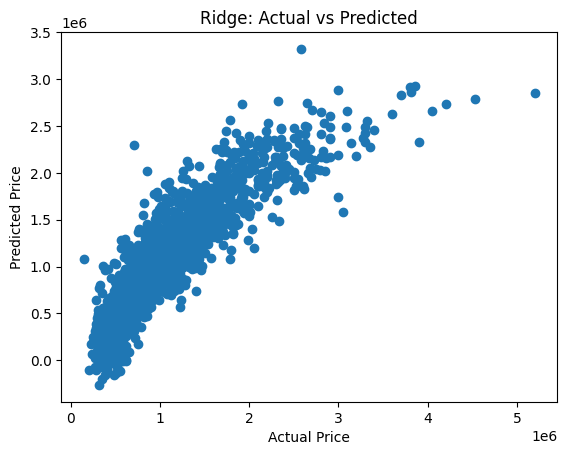

In [12]:
plt.figure()
plt.scatter(y_test, y_pred_ridge)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Ridge: Actual vs Predicted')
plt.show()